# 🎯 DQN WITH PRECEDENCE NETWORK — CartPole-v1

Entraîne DQN en utilisant le World Model (Precedence Network) pour **vérifier les actions AVANT exécution**.

✅ Teste les 3 configurations du World Model:
- **Config 1** : S(t+1) direct
- **Config 2** : S(t+5) direct  
- **Config 3** : ΔS = S(t+1) - St

✅ ActionVerifier : plusieurs stratégies de vérification

✅ Comparaison avec baseline (DQN sans precedence)

## 1. Imports & Setup

In [44]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import gymnasium as gym
import random
from collections import deque
from datetime import datetime

# ──────────────────────────────────────────────
# Configuration
# ──────────────────────────────────────────────
ENV_NAME = "CartPole-v1"
DATA_PATH = "../data/collected/CartPole"
CHECKPOINT_DIR = "checkpoints_with_precedence"
PLOT_DIR = "plots_with_precedence"
WORLD_MODEL_DIR = "world_model/checkpoints_CartPole"

# Hyperparamètres RL
N_EPISODES = 500
MAX_STEPS_PER_EPISODE = 500
BATCH_SIZE = 64
LR = 1e-3
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 0.995
TARGET_UPDATE = 10
BUFFER_SIZE = 50000

# Seed
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Créer répertoires
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# Random seed
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

print(f"✅ Setup OK")
print(f"  Device: {DEVICE}")
print(f"  Environment: {ENV_NAME}")
print(f"  Data path: {DATA_PATH}")

✅ Setup OK
  Device: cpu
  Environment: CartPole-v1
  Data path: ../data/collected/CartPole


## 2. Charger les données de normalisation

In [11]:
# Charger le scaler pour dénormaliser les états si nécessaire
scaler_path = os.path.join(DATA_PATH, "scaler.npz")
scaler = np.load(scaler_path, allow_pickle=True)

STATE_MEAN = scaler["state_mean"].astype(np.float32)
STATE_STD = scaler["state_std"].astype(np.float32)

# Dimensions
STATE_DIM = 4      # CartPole: 4D state
ACTION_DIM = 2     # CartPole: 2 actions

print(f"\n📦 Scaler chargé")
print(f"  STATE_DIM: {STATE_DIM}")
print(f"  ACTION_DIM: {ACTION_DIM}")
print(f"  State mean: {STATE_MEAN}")
print(f"  State std: {STATE_STD}")


📦 Scaler chargé
  STATE_DIM: 4
  ACTION_DIM: 2
  State mean: [-0.00020712 -0.02029223  0.00405843  0.02626351]
  State std: [0.48820907 0.80932426 0.12245946 0.66561514]


## 3. Architecture WorldModel (chargement)

In [37]:
class WorldModel(nn.Module):
    """
    Réseau de prédiction d'état (3 configs).

    Config 1 : in = obs_dim + act_dim          → S(t+1) absolu
    Config 2 : in = obs_dim + act_dim          → S(t+1) absolu (entraîné sur S(t+n))
    Config 3 : in = obs_dim + act_dim          → ΔS  (S+ΔS dans predict())
    """

    def __init__(self, obs_dim: int, act_dim: int,
                 config: int = 1,n_step: int = 5, hidden: int = 64):
        super().__init__()
        assert config in (1, 2, 3), "config doit être 1, 2 ou 3"

        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.config = config
        self.n_step = n_step

        if config == 2:
            in_dim = obs_dim + n_step * act_dim
        else:
            in_dim = obs_dim + act_dim


        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, obs_dim),
        )

    def forward(self, state: torch.Tensor,
                action_input: torch.Tensor) -> torch.Tensor:
        """
        state        : (batch, obs_dim)
        action_input : (batch, act_dim)
        retourne     : (batch, obs_dim)
        """
        return self.net(torch.cat([state, action_input], dim=-1))

    def predict(self, state: torch.Tensor,
                action_input: torch.Tensor) -> torch.Tensor:
        """Retourne toujours un état absolu (applique S+ΔS pour config 3)."""
        out = self.forward(state, action_input)
        return state + out if self.config == 3 else out


def load_world_model(config: int, checkpoint_dir=WORLD_MODEL_DIR):
    """
    Charger le world model entraîné pour une configuration donnée
    """
    model = WorldModel(STATE_DIM, ACTION_DIM, config=config, n_step=5, hidden=64).to(DEVICE)
    
    ckpt_path = os.path.join(checkpoint_dir, f"wm_{ENV_NAME}_config{config}.pt")
    if config == 2:
        ckpt_path = os.path.join(checkpoint_dir, f"wm_{ENV_NAME}_config{config}_n5.pt")
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=DEVICE,weights_only=False)
        print(ckpt.keys())
        print(ckpt["state_dict"]["net.0.weight"].shape)
        model.load_state_dict(ckpt["state_dict"])
        model.eval()
        print(f"✅ Config {config} world model chargé: {ckpt_path}")
        return model
    else:
        print(f"❌ Fichier non trouvé: {ckpt_path}")
        return None


print("✅ Architecture WorldModel définie")

✅ Architecture WorldModel définie


## 4. ActionVerifier - Stratégies de vérification

In [38]:
class ActionVerifier:
    """
    Vérifie si une action est "bonne" en prédisant le prochain état
    avec le World Model (Precedence Network).
    
    Plusieurs stratégies de vérification:
    1. Vérifier que l'état prédit reste dans les bounds de sécurité
    2. Vérifier la stabilité de la prédiction (itérations multiples)
    3. Vérifier que l'état prédit n'est pas un "terminal" prématuré
    """
    
    def __init__(self, world_model: WorldModel, config: int,
                 safety_threshold: float = 0.3,
                 stability_threshold: float = 0.5):
        """
        Args:
            world_model: le modèle de prédiction entraîné
            config: configuration du world model (1, 2, ou 3)
            safety_threshold: seuil pour considérer un état comme dangereux
            stability_threshold: seuil pour la stabilité de prédiction
        """
        self.model = world_model
        self.config = config
        self.safety_threshold = safety_threshold
        self.stability_threshold = stability_threshold
        
        # Stats pour CartPole
        self.pole_angle_safe_bound = 0.2  # ~12 degrés
        self.cart_position_safe_bound = 2.0
    
    @torch.no_grad()
    def predict_next_state(self, state_np: np.ndarray, action: int) -> tuple:
        """
        Prédire le prochain état avec le world model.
        
        Args:
            state_np: état courant (np.array, normalisé)
            action: action choisie (int, 0 ou 1)
        
        Returns:
            predicted_state_np: état prédit (np.array, normalisé)
            error: estimation d'erreur de prédiction
        """
        # Convertir en tenseur
        state_t = torch.FloatTensor(state_np).unsqueeze(0).to(DEVICE)  # (1, STATE_DIM)
        
        # One-hot encoding de l'action
        action_oh = torch.zeros(1, ACTION_DIM, device=DEVICE)
        action_oh[0, action] = 1.0
        
        # Prédiction
        with torch.no_grad():
            predicted_state_t = self.model.predict(state_t, action_oh)
        
        predicted_state_np = predicted_state_t.cpu().numpy()[0]
        
        return predicted_state_np, 0.0
    
    @torch.no_grad()
    def verify_action_cartpole(self, state_np: np.ndarray, action: int,
                                strategy: str = 'combined') -> tuple:
        """
        Vérifier si une action est bonne pour CartPole.
        
        Stratégies:
        - 'safety': vérifier que l'état reste dans les bounds
        - 'stability': vérifier la stabilité avec itérations multiples
        - 'combined': combinaison des deux
        
        Returns:
            is_valid: True si l'action est bonne
            confidence: score de confiance [0, 1]
            details: dict avec les détails de la vérification
        """
        details = {
            'strategy': strategy,
            'predicted_state': None,
            'pole_angle': None,
            'cart_position': None,
            'safety_ok': False,
            'stability_ok': False,
            'is_valid': False,
            'confidence': 0.0
        }
        
        # ════════════════════════════════════════════════════════════════
        # STRATÉGIE 1: VÉRIFICATION DE SÉCURITÉ
        # Vérifier que l'état prédit reste dans les bounds acceptables
        # ════════════════════════════════════════════════════════════════
        predicted_state, _ = self.predict_next_state(state_np, action)
        
        # CartPole state: [x, x_dot, theta, theta_dot]
        pole_angle = abs(predicted_state[2])         # theta
        cart_position = abs(predicted_state[0])      # x
        
        # Vérifier les bounds
        angle_ok = pole_angle < self.pole_angle_safe_bound
        position_ok = cart_position < self.cart_position_safe_bound
        safety_ok = angle_ok and position_ok
        
        details['predicted_state'] = predicted_state
        details['pole_angle'] = float(pole_angle)
        details['cart_position'] = float(cart_position)
        details['safety_ok'] = bool(safety_ok)
        
        if strategy in ['safety', 'combined']:
            if not safety_ok:
                details['is_valid'] = False
                details['confidence'] = 0.0 if not safety_ok else 0.5
                return False, 0.0, details
        
        # ════════════════════════════════════════════════════════════════
        # STRATÉGIE 2: VÉRIFICATION DE STABILITÉ
        # Prédire plusieurs fois avec perturbations légères et vérifier
        # que les prédictions convergent
        # ════════════════════════════════════════════════════════════════
        if strategy in ['stability', 'combined']:
            predictions = []
            n_iterations = 5
            
            for i in range(n_iterations):
                # Ajouter petit bruit au state pour tester robustesse
                noise_scale = 0.01 if i > 0 else 0.0
                perturbed_state = state_np + np.random.randn(STATE_DIM) * noise_scale
                
                pred, _ = self.predict_next_state(perturbed_state, action)
                predictions.append(pred)
            
            # Calculer la variance des prédictions
            predictions_arr = np.array(predictions)  # (n_iterations, STATE_DIM)
            variance = np.mean(np.var(predictions_arr, axis=0))  # moyenne des variances
            
            stability_ok = variance < self.stability_threshold
            details['stability_ok'] = bool(stability_ok)
            details['prediction_variance'] = float(variance)
            
            if not stability_ok and strategy == 'stability':
                details['is_valid'] = False
                details['confidence'] = 0.5
                return False, 0.5, details
        
        # ════════════════════════════════════════════════════════════════
        # DÉCISION FINALE
        # ════════════════════════════════════════════════════════════════
        if strategy == 'safety':
            is_valid = safety_ok
            confidence = 1.0 if is_valid else 0.0
        
        elif strategy == 'stability':
            is_valid = stability_ok
            confidence = 1.0 - min(variance / self.stability_threshold, 1.0)
        
        elif strategy == 'combined':
            is_valid = safety_ok  # Safety est la priorité
            # Confidence = moyenne de safety et stability scores
            safety_score = 1.0 if safety_ok else 0.0
            stability_score = 1.0 - min(variance / self.stability_threshold, 1.0) if 'prediction_variance' in details else 0.5
            confidence = (safety_score + stability_score) / 2.0
        
        details['is_valid'] = bool(is_valid)
        details['confidence'] = float(confidence)
        
        return is_valid, confidence, details


print("✅ ActionVerifier défini avec 3 stratégies")

✅ ActionVerifier défini avec 3 stratégies


## 5. DQN Agent

In [39]:
class ReplayBuffer:
    """Circular replay buffer for experience storage."""
    
    def __init__(self, capacity: int = BUFFER_SIZE):
        self.buffer = deque(maxlen=capacity)
    
    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int32),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32),
        )
    
    def __len__(self):
        return len(self.buffer)


class QNetwork(nn.Module):
    """Q-network for CartPole."""
    
    def __init__(self, state_dim: int, action_dim: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, action_dim),
        )
    
    def forward(self, x):
        return self.net(x)


class DQNAgent:
    """DQN Agent with optional precedence network verification."""
    
    def __init__(self, use_precedence: bool = False,
                 world_model: WorldModel = None,
                 verifier: ActionVerifier = None,
                 verify_strategy: str = 'combined'):
        
        self.state_dim = STATE_DIM
        self.action_dim = ACTION_DIM
        self.use_precedence = use_precedence
        self.world_model = world_model
        self.verifier = verifier
        self.verify_strategy = verify_strategy
        
        # Q-networks
        self.q_net = QNetwork(STATE_DIM, ACTION_DIM).to(DEVICE)
        self.target_net = QNetwork(STATE_DIM, ACTION_DIM).to(DEVICE)
        self.target_net.load_state_dict(self.q_net.state_dict())
        
        # Optimizer
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=LR)
        self.criterion = nn.MSELoss()
        
        # RL parameters
        self.epsilon = EPSILON_START
        self.gamma = GAMMA
        
        # Replay buffer
        self.replay_buffer = ReplayBuffer(BUFFER_SIZE)
        
        # Stats
        self.actions_verified = 0
        self.actions_skipped = 0  # Actions rejected by verifier
        self.actions_executed_unsafe = 0  # Actions executed without verification
        self.verification_history = []  # Track verification details
    
    def select_action_epsilon_greedy(self, state: np.ndarray) -> int:
        """
        Standard ε-greedy action selection (no precedence verification).
        """
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)
        
        state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            q_values = self.q_net(state_t)
            return q_values.argmax(1).item()
    
    def select_action_with_verification(self, state: np.ndarray) -> tuple:
        """
        Sélectionner une action ET la vérifier avec le precedence network.
        
        Returns:
            action: action choisie
            is_verified: True si l'action a été vérifiée et approuvée
            details: dict avec détails de vérification
        """
        # Obtenir l'action recommandée
        if np.random.random() < self.epsilon:
            recommended_action = np.random.randint(self.action_dim)
        else:
            state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                q_values = self.q_net(state_t)
                recommended_action = q_values.argmax(1).item()
        
        # Vérifier l'action recommandée
        is_valid, confidence, details = self.verifier.verify_action_cartpole(
            state, recommended_action, strategy=self.verify_strategy
        )
        
        details['recommended_action'] = recommended_action
        
        if is_valid:
            # ✅ Action vérifiée, l'exécuter
            self.actions_verified += 1
            self.verification_history.append(details)
            return recommended_action, True, details
        
        else:
            # ❌ Action rejetée, essayer les alternatives
            alternative_actions = [a for a in range(self.action_dim) if a != recommended_action]
            
            for alt_action in alternative_actions:
                is_valid, confidence, details_alt = self.verifier.verify_action_cartpole(
                    state, alt_action, strategy=self.verify_strategy
                )
                
                if is_valid:
                    # ✅ Action alternative trouvée et vérifiée
                    self.actions_verified += 1
                    details_alt['recommended_action'] = recommended_action
                    details_alt['alternative_action'] = alt_action
                    self.verification_history.append(details_alt)
                    return alt_action, True, details_alt
            
            # ⚠️ Aucune action vérifiée, exécuter l'action recommandée quand même
            self.actions_skipped += 1
            details['recommended_action'] = recommended_action
            details['no_valid_alternative'] = True
            self.verification_history.append(details)
            return recommended_action, False, details
    
    def store_experience(self, state, action, reward, next_state, done):
        """Store transition in replay buffer."""
        self.replay_buffer.add(state, action, reward, next_state, done)
    
    def train_step(self) -> float:
        """Perform one DQN training step."""
        if len(self.replay_buffer) < BATCH_SIZE:
            return None
        
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(BATCH_SIZE)
        
        states_t = torch.FloatTensor(states).to(DEVICE)
        actions_t = torch.LongTensor(actions).to(DEVICE)
        rewards_t = torch.FloatTensor(rewards).to(DEVICE)
        next_states_t = torch.FloatTensor(next_states).to(DEVICE)
        dones_t = torch.FloatTensor(dones).to(DEVICE)
        
        # Compute Q(s,a)
        q_values = self.q_net(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)
        
        # Compute target Q(s',a')
        with torch.no_grad():
            best_actions = self.q_net(next_states_t).argmax(1)
            max_q_next = self.target_net(next_states_t).gather(1, best_actions.unsqueeze(1)).squeeze(1)
            target_q = rewards_t + self.gamma * max_q_next * (1 - dones_t)
        
        loss = self.criterion(q_values, target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), 1.0)
        self.optimizer.step()
        
        return loss.item()
    
    def update_target_network(self):
        """Update target network weights."""
        self.target_net.load_state_dict(self.q_net.state_dict())
    
    def decay_epsilon(self):
        """Decay exploration rate."""
        self.epsilon = max(EPSILON_END, self.epsilon * EPSILON_DECAY)


print("✅ DQN Agent défini")

✅ DQN Agent défini


## 6. Entraînement - Config 1 (S(t+1) direct)

In [45]:
def train_dqn_episode(agent: DQNAgent, env, max_steps: int = MAX_STEPS_PER_EPISODE,
                     use_precedence: bool = False) -> tuple:
    """
    Entraîner un épisode DQN.
    
    Returns:
        episode_reward: reward total de l'épisode
        actions_verified: nombre d'actions vérifiées
        actions_skipped: nombre d'actions rejetées
    """
    state, _ = env.reset()
    state_norm = (state - STATE_MEAN) / (STATE_STD + 1e-8)  # Normaliser
    
    episode_reward = 0
    verified_count = 0
    skipped_count = 0
    
    for step in range(max_steps):
        if use_precedence:
            # AVEC verification du precedence network
            action, is_verified, details = agent.select_action_with_verification(state_norm)
            if is_verified:
                verified_count += 1
            else:
                skipped_count += 1
        else:
            # SANS verification (baseline)
            action = agent.select_action_epsilon_greedy(state_norm)
        
        # Exécuter l'action dans l'environnement
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        # Normaliser l'état suivant
        next_state_norm = (next_state - STATE_MEAN) / (STATE_STD + 1e-8)
        
        # Stocker la transition
        agent.store_experience(state_norm, action, reward, next_state_norm, done)
        
        # Entraîner
        if len(agent.replay_buffer) > 64:
            agent.train_step()
        
        episode_reward += reward
        state_norm = next_state_norm
        
        if done:
            break
    
    return episode_reward, verified_count, skipped_count


def train_agent_with_config(config: int, use_precedence: bool = False,
                          verify_strategy: str = 'combined',
                          n_episodes: int = N_EPISODES):
    """
    Entraîner un agent DQN avec une configuration du world model donnée.
    """
    print(f"\n{'='*80}")
    print(f"  DQN Training — Config {config} | Use Precedence: {use_precedence}")
    print(f"  Environment: {ENV_NAME}")
    if use_precedence:
        print(f"  Verification Strategy: {verify_strategy}")
    print(f"{'='*80}\n")
    
    env = gym.make(ENV_NAME)
    
    # Charger le world model
    world_model = load_world_model(config)
    if world_model is None:
        print(f"❌ Impossible de charger le world model pour config {config}")
        return None
    
    # Créer l'agent
    agent = DQNAgent(
        use_precedence=use_precedence,
        world_model=world_model if use_precedence else None,
        verifier=None
    )
    
    # Créer le verifier si needed
    if use_precedence:
        agent.verifier = ActionVerifier(
            world_model,
            config=config,
            safety_threshold=0.3,
            stability_threshold=0.5
        )
        agent.verify_strategy = verify_strategy
    
    episode_rewards = []
    episode_verified = []
    episode_skipped = []
    total_loss = []
    update_counter = 0
    
    for episode in range(n_episodes):
        episode_reward, verified, skipped = train_dqn_episode(
            agent, env, use_precedence=use_precedence
        )
        
        episode_rewards.append(episode_reward)
        episode_verified.append(verified)
        episode_skipped.append(skipped)
        
        # Train
        for _ in range(10):
            loss = agent.train_step()
            if loss is not None:
                total_loss.append(loss)
        
        # Update target network
        if (episode + 1) % TARGET_UPDATE == 0:
            agent.update_target_network()
        
        # Decay epsilon
        agent.decay_epsilon()
        
        # Log
        if (episode + 1) % 20 == 0:
            avg_reward = np.mean(episode_rewards[-20:])
            print(f"  Episode {episode+1:3d}/{n_episodes} | "
                  f"Avg Reward: {avg_reward:7.2f} | "
                  f"ε: {agent.epsilon:.3f}", end="")
            if use_precedence:
                avg_verified = np.mean(episode_verified[-20:])
                avg_skipped = np.mean(episode_skipped[-20:])
                print(f" | Verified: {avg_verified:.1f} | Skipped: {avg_skipped:.1f}")
            else:
                print()
    
    env.close()
    
    return {
        'config': config,
        'use_precedence': use_precedence,
        'agent': agent,
        'rewards': episode_rewards,
        'verified': episode_verified,
        'skipped': episode_skipped,
        'losses': total_loss,
    }


# ════════════════════════════════════════════════════════════════════════════════════
# ENTRAÎNER POUR CONFIG 1
# ════════════════════════════════════════════════════════════════════════════════════
results_config1_with_prec = train_agent_with_config(
    config=1,
    use_precedence=True,
    verify_strategy='combined',
    n_episodes=N_EPISODES
)


  DQN Training — Config 1 | Use Precedence: True
  Environment: CartPole-v1
  Verification Strategy: combined

dict_keys(['state_dict', 'config', 'obs_dim', 'act_dim', 'hidden', 'state_mean', 'state_std'])
torch.Size([64, 6])
✅ Config 1 world model chargé: world_model/checkpoints_CartPole/wm_CartPole-v1_config1.pt
  Episode  20/500 | Avg Reward:   24.20 | ε: 0.905 | Verified: 5.8 | Skipped: 18.4
  Episode  40/500 | Avg Reward:   28.95 | ε: 0.818 | Verified: 5.9 | Skipped: 23.1
  Episode  60/500 | Avg Reward:   24.05 | ε: 0.740 | Verified: 4.8 | Skipped: 19.2
  Episode  80/500 | Avg Reward:   23.15 | ε: 0.670 | Verified: 4.0 | Skipped: 19.2
  Episode 100/500 | Avg Reward:   53.60 | ε: 0.606 | Verified: 9.8 | Skipped: 43.8
  Episode 120/500 | Avg Reward:   45.30 | ε: 0.548 | Verified: 4.8 | Skipped: 40.5
  Episode 140/500 | Avg Reward:   50.35 | ε: 0.496 | Verified: 6.0 | Skipped: 44.3
  Episode 160/500 | Avg Reward:   42.60 | ε: 0.448 | Verified: 5.0 | Skipped: 37.5
  Episode 180/500 |

## 7. Entraînement - Config 2 (S(t+n) direct)

In [41]:
# ════════════════════════════════════════════════════════════════════════════════════
# ENTRAÎNER POUR CONFIG 2
# ════════════════════════════════════════════════════════════════════════════════════
results_config2_with_prec = train_agent_with_config(
    config=2,
    use_precedence=True,
    verify_strategy='combined',
    n_episodes=N_EPISODES
)


  DQN Training — Config 2 | Use Precedence: True
  Environment: CartPole-v1
  Verification Strategy: combined

dict_keys(['state_dict', 'config', 'obs_dim', 'act_dim', 'hidden', 'state_mean', 'state_std'])
torch.Size([64, 14])
✅ Config 2 world model chargé: world_model/checkpoints_CartPole/wm_CartPole-v1_config2_n5.pt


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x6 and 14x64)

## 8. Entraînement - Config 3 (ΔS)

In [46]:
# ════════════════════════════════════════════════════════════════════════════════════
# ENTRAÎNER POUR CONFIG 3
# ════════════════════════════════════════════════════════════════════════════════════
results_config3_with_prec = train_agent_with_config(
    config=3,
    use_precedence=True,
    verify_strategy='combined',
    n_episodes=N_EPISODES
)


  DQN Training — Config 3 | Use Precedence: True
  Environment: CartPole-v1
  Verification Strategy: combined

dict_keys(['state_dict', 'config', 'obs_dim', 'act_dim', 'hidden', 'state_mean', 'state_std'])
torch.Size([64, 6])
✅ Config 3 world model chargé: world_model/checkpoints_CartPole/wm_CartPole-v1_config3.pt
  Episode  20/500 | Avg Reward:   20.95 | ε: 0.905 | Verified: 5.2 | Skipped: 15.8
  Episode  40/500 | Avg Reward:   31.95 | ε: 0.818 | Verified: 8.9 | Skipped: 23.1
  Episode  60/500 | Avg Reward:   31.85 | ε: 0.740 | Verified: 6.2 | Skipped: 25.6
  Episode  80/500 | Avg Reward:   37.70 | ε: 0.670 | Verified: 6.4 | Skipped: 31.3
  Episode 100/500 | Avg Reward:   41.90 | ε: 0.606 | Verified: 6.3 | Skipped: 35.5
  Episode 120/500 | Avg Reward:   49.05 | ε: 0.548 | Verified: 6.0 | Skipped: 43.0
  Episode 140/500 | Avg Reward:   47.80 | ε: 0.496 | Verified: 4.8 | Skipped: 43.0
  Episode 160/500 | Avg Reward:   58.95 | ε: 0.448 | Verified: 4.5 | Skipped: 54.4
  Episode 180/500 |

## 9. Analyse & Comparaison

In [47]:
# ════════════════════════════════════════════════════════════════════════════════════
# RÉSUMÉ DES 3 CONFIGURATIONS - WITH PRECEDENCE
# ════════════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*80}")
print(f"  RÉSUMÉ — DQN WITH PRECEDENCE NETWORK — {ENV_NAME}")
print(f"{'='*80}\n")

all_results = [
    results_config1_with_prec,
    results_config2_with_prec,
    results_config3_with_prec,
]

for res in all_results:
    if res is None:
        continue
    
    config = res['config']
    rewards = res['rewards']
    verified = res['verified']
    skipped = res['skipped']
    
    final_reward = np.mean(rewards[-50:])
    final_std = np.std(rewards[-50:])
    avg_verified = np.mean(verified[-50:])
    avg_skipped = np.mean(skipped[-50:])
    
    print(f"Config {config}:")
    print(f"  Final Reward:     {final_reward:.2f} ± {final_std:.2f}")
    print(f"  Avg Verified:     {avg_verified:.1f} actions/episode")
    print(f"  Avg Skipped:      {avg_skipped:.1f} actions/episode")
    print(f"  Total Steps:      {np.sum(rewards)}")
    print()

# Trouver la meilleure config
best_config = max(all_results, key=lambda x: np.mean(x['rewards'][-50:]) if x else -float('inf'))
print(f"🏆 Meilleure config: Config {best_config['config']}")
print(f"   Reward final: {np.mean(best_config['rewards'][-50:]):.2f}")


  RÉSUMÉ — DQN WITH PRECEDENCE NETWORK — CartPole-v1

Config 1:
  Final Reward:     92.26 ± 61.45
  Avg Verified:     8.6 actions/episode
  Avg Skipped:      83.7 actions/episode
  Total Steps:      33872.0

Config 3:
  Final Reward:     126.26 ± 112.22
  Avg Verified:     9.3 actions/episode
  Avg Skipped:      117.0 actions/episode
  Total Steps:      40112.0

🏆 Meilleure config: Config 3
   Reward final: 126.26


## 10. Visualisations

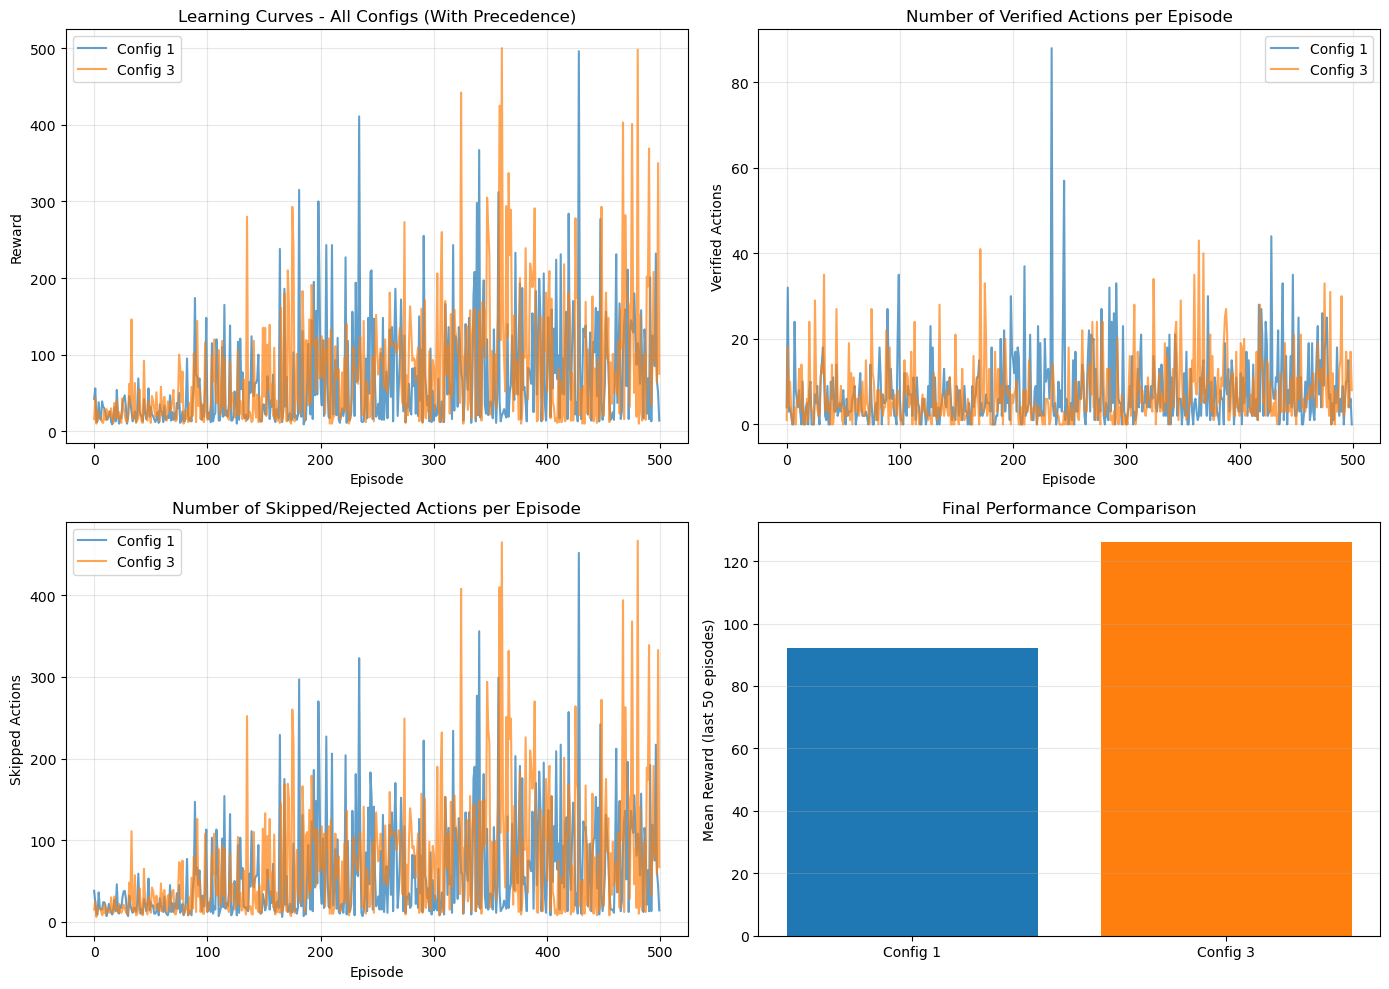

📊 Plot saved → plots_with_precedence/all_configs_with_precedence.png


In [48]:
# ════════════════════════════════════════════════════════════════════════════════════
# PLOTS
# ════════════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Rewards comparison
ax = axes[0, 0]
for res in all_results:
    if res is None:
        continue
    ax.plot(res['rewards'], alpha=0.7, label=f"Config {res['config']}")
ax.set_xlabel('Episode')
ax.set_ylabel('Reward')
ax.set_title('Learning Curves - All Configs (With Precedence)')
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Verified actions
ax = axes[0, 1]
for res in all_results:
    if res is None:
        continue
    ax.plot(res['verified'], alpha=0.7, label=f"Config {res['config']}")
ax.set_xlabel('Episode')
ax.set_ylabel('Verified Actions')
ax.set_title('Number of Verified Actions per Episode')
ax.legend()
ax.grid(alpha=0.3)

# Plot 3: Skipped actions
ax = axes[1, 0]
for res in all_results:
    if res is None:
        continue
    ax.plot(res['skipped'], alpha=0.7, label=f"Config {res['config']}")
ax.set_xlabel('Episode')
ax.set_ylabel('Skipped Actions')
ax.set_title('Number of Skipped/Rejected Actions per Episode')
ax.legend()
ax.grid(alpha=0.3)

# Plot 4: Final rewards comparison (bar chart)
ax = axes[1, 1]
configs = []
final_rewards = []
for res in all_results:
    if res is None:
        continue
    configs.append(f"Config {res['config']}")
    final_rewards.append(np.mean(res['rewards'][-50:]))

ax.bar(configs, final_rewards, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_ylabel('Mean Reward (last 50 episodes)')
ax.set_title('Final Performance Comparison')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'all_configs_with_precedence.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"📊 Plot saved → {os.path.join(PLOT_DIR, 'all_configs_with_precedence.png')}")

## 11. Detailed Analysis - Verification Statistics

In [49]:
# ════════════════════════════════════════════════════════════════════════════════════
# ANALYSE DÉTAILLÉE - STATISTIQUES DE VÉRIFICATION
# ════════════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*80}")
print(f"  DETAILED VERIFICATION ANALYSIS")
print(f"{'='*80}\n")

for res in all_results:
    if res is None:
        continue
    
    config = res['config']
    agent = res['agent']
    
    print(f"\n📊 Config {config} Analysis:")
    print("-" * 80)
    
    # Analyse du historique de vérification
    if len(agent.verification_history) > 0:
        
        # Compter les types de vérification
        safety_count = sum(1 for v in agent.verification_history if v.get('safety_ok', False))
        stability_count = sum(1 for v in agent.verification_history if v.get('stability_ok', False))
        invalid_count = sum(1 for v in agent.verification_history if not v.get('is_valid', True))
        
        print(f"  Total verifications: {len(agent.verification_history)}")
        print(f"  - Safety passed: {safety_count} ({100*safety_count/len(agent.verification_history):.1f}%)")
        print(f"  - Stability passed: {stability_count} ({100*stability_count/len(agent.verification_history):.1f}%)")
        print(f"  - Total invalid: {invalid_count} ({100*invalid_count/len(agent.verification_history):.1f}%)")
        
        # Statistiques sur les angles prédits
        pole_angles = [v.get('pole_angle', 0) for v in agent.verification_history]
        cart_positions = [v.get('cart_position', 0) for v in agent.verification_history]
        
        print(f"\n  Predicted pole angles (mean ± std): {np.mean(pole_angles):.4f} ± {np.std(pole_angles):.4f}")
        print(f"  Predicted cart positions (mean ± std): {np.mean(cart_positions):.4f} ± {np.std(cart_positions):.4f}")
    
    print(f"\n  Actions verified: {agent.actions_verified}")
    print(f"  Actions skipped: {agent.actions_skipped}")
    print(f"  Actions executed unsafe: {agent.actions_executed_unsafe}")

print(f"\n{'='*80}")


  DETAILED VERIFICATION ANALYSIS


📊 Config 1 Analysis:
--------------------------------------------------------------------------------
  Total verifications: 33872
  - Safety passed: 3811 (11.3%)
  - Stability passed: 3811 (11.3%)
  - Total invalid: 30061 (88.7%)

  Predicted pole angles (mean ± std): 0.8431 ± 0.4965
  Predicted cart positions (mean ± std): 0.9911 ± 1.1451

  Actions verified: 3811
  Actions skipped: 30061
  Actions executed unsafe: 0

📊 Config 3 Analysis:
--------------------------------------------------------------------------------
  Total verifications: 40112
  - Safety passed: 3602 (9.0%)
  - Stability passed: 3602 (9.0%)
  - Total invalid: 36510 (91.0%)

  Predicted pole angles (mean ± std): 0.8141 ± 0.4758
  Predicted cart positions (mean ± std): 1.0599 ± 1.2185

  Actions verified: 3602
  Actions skipped: 36510
  Actions executed unsafe: 0



## 12. Save Results

In [50]:
# ════════════════════════════════════════════════════════════════════════════════════
# SAUVEGARDER LES RÉSULTATS
# ════════════════════════════════════════════════════════════════════════════════════

import json

def save_results(results_list, filename):
    """
    Sauvegarder les résultats d'entraînement pour comparaison future.
    """
    save_data = {}
    
    for res in results_list:
        if res is None:
            continue
        
        config = res['config']
        save_data[f"config_{config}"] = {
            'rewards': [float(r) for r in res['rewards']],
            'verified': [int(v) for v in res['verified']],
            'skipped': [int(s) for s in res['skipped']],
            'final_reward_mean': float(np.mean(res['rewards'][-50:])),
            'final_reward_std': float(np.std(res['rewards'][-50:])),
            'total_verified': int(sum(res['verified'])),
            'total_skipped': int(sum(res['skipped'])),
        }
    
    with open(os.path.join(CHECKPOINT_DIR, filename), 'w') as f:
        json.dump(save_data, f, indent=4)
    
    print(f"✅ Results saved → {os.path.join(CHECKPOINT_DIR, filename)}")


save_results(
    [results_config1_with_prec, results_config2_with_prec, results_config3_with_prec],
    'dqn_with_precedence_results.json'
)

print(f"\n✅ Training complete!")
print(f"  Checkpoints: {CHECKPOINT_DIR}")
print(f"  Plots: {PLOT_DIR}")

✅ Results saved → checkpoints_with_precedence/dqn_with_precedence_results.json

✅ Training complete!
  Checkpoints: checkpoints_with_precedence
  Plots: plots_with_precedence
